# Download biblioteca

# Importar dados

In [1]:
import pandas as pd
import os
import numpy as np
import random

In [2]:

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
caminho_dados = '/content/drive/Shareddrives/IC - Otimizacao computacional para inflacao/Dados/dados_USA'

# Listar os arquivos dentro da pasta "Dados"
arquivos_dados = os.listdir(caminho_dados)

print(arquivos_dados)


['Untitled0.ipynb', 'dados_macroeconomicos_usa.csv']


In [4]:
# Caminho para o arquivo CSV
caminho_arquivo = os.path.join(caminho_dados, 'dados_macroeconomicos_usa.csv')

# Ler o arquivo CSV
df = pd.read_csv(caminho_arquivo)

In [5]:
df = df.set_index('DATE')
df.drop(columns=['Unnamed: 0'], inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 180 entries, 2010-01-01 to 2024-12-01
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Inflacao_CPI                 180 non-null    float64
 1   Inflacao_CPI_Core            180 non-null    float64
 2   PCE_Core                     180 non-null    float64
 3   Desemprego                   180 non-null    float64
 4   Desemprego_menos_27_semanas  180 non-null    float64
 5   Taxa_Juros_Fed               180 non-null    float64
 6   Emprego_Total_Nao_Agricola   180 non-null    int64  
 7   Permissoes_Construcao        180 non-null    int64  
 8   Salario_Medio                180 non-null    float64
 9   Salario_Medio_Real_Hora      180 non-null    float64
 10  Producao_Industrial          180 non-null    float64
 11  Capacidade_Instalada         180 non-null    float64
 12  PCE                          180 non-null    float64
 13  Deflator_

# Importar bibliotecas

In [6]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso

# Divisao e normalizacao dos dados

In [7]:

# 📌 Preparação dos dados
X = df.drop(columns=['Inflacao_CPI'])  # Removendo Inflacao_CPI das features
y = df['Inflacao_CPI']

# Divisão entre treino e teste (SÉRIE TEMPORAL, sem shuffle)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

In [8]:
# 📌 Normalização dos dados
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)


# Modelo Lasso

In [9]:
# 📌 Modelo de regressão
lasso_model = Lasso(alpha=0.1, random_state=42)

In [11]:
X_selected = ['Taxa_Juros_Fed', 'Emprego_Total_Nao_Agricola', 'Salario_Medio', 'Producao_Industrial', 'Capacidade_Instalada']
X_sub = X_train_scaled[X_selected]
lasso_model.fit(X_sub, y_train)

Lasso(alpha=0.1, random_state=42)

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
X_sub = X_test_scaled[X_selected]
# Fazendo previsões no conjunto de teste
y_pred = lasso_model.predict(X_sub)

# MAE
mae = mean_absolute_error(y_test, y_pred)

# MSE
mse = mean_squared_error(y_test, y_pred)

# RMSE
rmse = np.sqrt(mse)

# MAPE
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

# Exibindo os resultados
print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.2f}%")


MAE:  15.7508
MSE:  265.9510
RMSE: 16.3080
MAPE: 5.15%


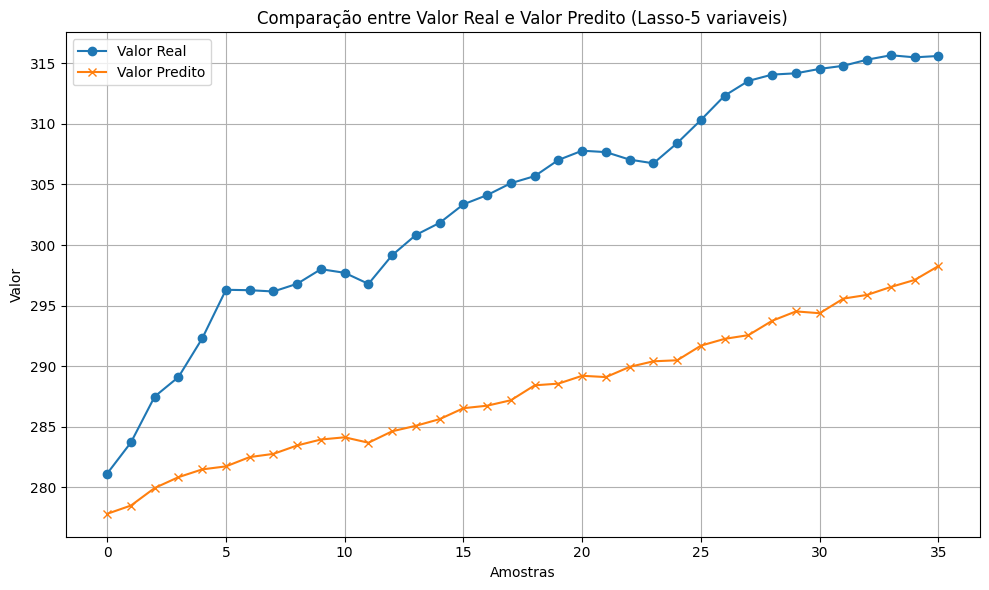

In [13]:
import matplotlib.pyplot as plt

# Plot
plt.figure(figsize=(10, 6))
plt.plot(y_test.values, label='Valor Real', marker='o')
plt.plot(y_pred, label='Valor Predito', marker='x')
plt.title('Comparação entre Valor Real e Valor Predito (Lasso-5 variaveis)')
plt.xlabel('Amostras')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
